In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from tqdm import tqdm
import math
from scformer.ggtransformer import HGTTransformer
from scformer.utils import *

import pandas as pd

from scformer.utils import *
from warnings import filterwarnings
import random
import os
import torch
import torch.cuda as cuda
from scipy import sparse

In [2]:
from scipy import sparse
from tqdm import tqdm


class NodeDimensionReduction(nn.Module):
    def __init__(self, RNA_matrix, indices, ini_p1, n_hid, n_heads,
                 n_layers, labsm, lr, wd, device, num_types=2, num_relations=2, epochs=1):
        super(NodeDimensionReduction, self).__init__()
        self.RNA_matrix = RNA_matrix
        self.indices = indices
        self.ini_p1 = ini_p1

        # 获取输入维度
        self.gene_dim = RNA_matrix.shape[1]  # 基因特征维度
        self.cell_dim = RNA_matrix.shape[0]  # 细胞特征维度

        # 添加特征转换层
        self.gene_transform = nn.Linear(self.gene_dim, n_hid).to(device)
        self.cell_transform = nn.Linear(self.cell_dim, n_hid).to(device)

        self.n_hid = n_hid
        self.num_types = num_types
        self.num_relations = num_relations
        self.n_heads = n_heads
        self.n_layers = n_layers
        self.labsm = labsm
        self.lr = lr
        self.wd = wd
        self.device = device
        self.epochs = epochs

        # 标签平滑
        self.LabSm = LabelSmoothing(self.labsm)

        # HGT Transformer
        self.gnn = HGTTransformer(
            in_dim=n_hid,
            out_dim=n_hid,
            num_types=self.num_types,
            num_relations=self.num_relations,
            n_heads=self.n_heads,
            num_layers=self.n_layers,
            dropout=0.3).to(self.device)

        # 优化器
        self.optimizer = torch.optim.AdamW(
            list(self.gene_transform.parameters()) +
            list(self.cell_transform.parameters()) +
            list(self.gnn.parameters()),
            lr=self.lr,
            weight_decay=self.wd
        )

        # 学习率调度器
        self.scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            self.optimizer, 'min', factor=0.5, patience=5, verbose=True
        )

    def preprocess_features(self, features, is_gene=True):
        """预处理特征"""
        # 转换为密集张量
        if sparse.issparse(features):
            features = features.todense()
        features = torch.tensor(features, dtype=torch.float32).to(self.device)

        # 标准化
        features = features / (features.sum(dim=1, keepdim=True) + 1e-6)

        # 对数转换
        features = torch.log1p(features * 10000)

        # 维度转换
        if is_gene:
            features = self.gene_transform(features)
        else:
            features = self.cell_transform(features)

        return features

    def train_model(self, n_batch):
        print('Starting NodeDimensionReduction model training...')
        h_final = None

        for epoch in tqdm(range(self.epochs)):
            epoch_loss = 0
            for batch_id in range(n_batch):
                # 获取批次索引
                gene_index = self.indices[batch_id]['gene_index']
                cell_index = self.indices[batch_id]['cell_index']

                # 提取并预处理特征
                gene_feature = self.preprocess_features(
                    self.RNA_matrix[list(gene_index), :], is_gene=True
                )
                cell_feature = self.preprocess_features(
                    self.RNA_matrix[:, list(cell_index)].T, is_gene=False
                )

                # 构建节点特征
                node_feature = [cell_feature, gene_feature]

                # 构建子图
                gene_cell_sub = self.RNA_matrix[list(gene_index), :][:, list(cell_index)]

                # 构建边索引
                edge_index, edge_type = self._build_graph_structure(
                    gene_cell_sub, len(cell_index), len(gene_index)
                )

                # 构建节点类型
                node_type = torch.LongTensor(
                    np.concatenate([
                        np.zeros(len(cell_index)),
                        np.ones(len(gene_index))
                    ])
                ).to(self.device)

                # 获取标签
                labels = torch.LongTensor(
                    np.array(self.ini_p1)[cell_index]
                ).to(self.device)

                # 前向传播
                node_rep = self.gnn(node_feature, node_type, edge_index, edge_type)

                # 分离细胞和基因嵌入
                cell_emb = node_rep[node_type == 0]
                gene_emb = node_rep[node_type == 1]

                # 计算损失
                loss = self._compute_loss(
                    cell_emb, gene_emb, gene_cell_sub, labels
                )

                # 更新
                self.optimizer.zero_grad()
                loss.backward()
                self.optimizer.step()

                epoch_loss += loss.item()

                # 保存最后一个批次的嵌入
                h_final = cell_emb[labels == labels[-1]]

            # 更新学习率
            self.scheduler.step(epoch_loss / n_batch)

        print('Training completed.')
        return self.gnn, cell_emb, gene_emb, h_final

    def _build_graph_structure(self, gene_cell_sub, n_cells, n_genes):
        """构建图结构"""
        # 基因到细胞的边
        gene_to_cell = np.nonzero(gene_cell_sub)
        gene_to_cell_src = gene_to_cell[0] + n_cells
        gene_to_cell_dst = gene_to_cell[1]

        # 细胞到基因的边
        cell_to_gene_src = gene_to_cell_dst
        cell_to_gene_dst = gene_to_cell_src

        # 合并边
        edge_index = torch.LongTensor([
            np.concatenate([gene_to_cell_src, cell_to_gene_src]),
            np.concatenate([gene_to_cell_dst, cell_to_gene_dst])
        ]).to(self.device)

        # 边类型
        edge_type = torch.LongTensor(
            np.concatenate([
                np.zeros(len(gene_to_cell_src)),
                np.ones(len(cell_to_gene_src))
            ])
        ).to(self.device)

        return edge_index, edge_type

    def _compute_loss(self, cell_emb, gene_emb, gene_cell_sub, labels):
        """计算损失"""
        # 重建损失
        decoder_gene_to_cell = torch.mm(gene_emb, cell_emb.t())
        decoder_cell_to_gene = torch.mm(cell_emb, gene_emb.t())

        gene_cell_sub_tensor = torch.tensor(
            gene_cell_sub.todense(), dtype=torch.float32
        ).to(self.device)

        # KL散度损失
        loss_kl1 = F.kl_div(
            F.log_softmax(decoder_gene_to_cell, dim=-1),
            F.softmax(gene_cell_sub_tensor, dim=-1),
            reduction='mean'
        )

        loss_kl2 = F.kl_div(
            F.log_softmax(decoder_cell_to_gene, dim=-1),
            F.softmax(gene_cell_sub_tensor.t(), dim=-1),
            reduction='mean'
        )

        loss_kl = loss_kl1 + loss_kl2

        # 聚类损失
        loss_cluster = self.LabSm(cell_emb, labels)

        # 相似度损失
        similarity_loss = 0
        for label in torch.unique(labels):
            mask = (labels == label)
            h = cell_emb[mask]
            if h.size(0) > 1:
                similarity = F.cosine_similarity(
                    h.unsqueeze(1),
                    h.unsqueeze(0),
                    dim=-1
                )
                similarity_loss += similarity.mean()

        return loss_cluster - similarity_loss + loss_kl

In [3]:
filterwarnings("ignore")
seed = 0
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
os.environ['PYTHONHASHSEED'] = str(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = True

In [4]:
gene_cell = ad.read_mtx('data/mouse_retina/Gene_Cell.mtx')
gene_names = pd.read_csv('data/mouse_retina/Gene_names.tsv', sep='\t', header=None)
true_label = pd.read_csv('data/mouse_retina/Cell_type.tsv', sep='\t', header=None)

gene_cell.obs_names = gene_names[0]

RNA_matrix = gene_cell.X

cell_num = RNA_matrix.shape[1]
gene_num = RNA_matrix.shape[0]
cell_num

9383

In [5]:
initial_pre = initial_clustering(RNA_matrix)
cluster_ini_num = len(set(initial_pre))
ini_p1 = [int(i) for i in initial_pre]
# partite the data into batches
indices, Node_Ids, dic = batch_select_whole(RNA_matrix)
n_batch = len(indices)
device = torch.device("cuda" if cuda.is_available() else "cpu")

	When the number of cells is less than or equal to 500, it is recommended to set the resolution value to 0.2.
	When the number of cells is within the range of 500 to 5000, the resolution value should be set to 0.5.
	When the number of cells is greater than 5000, the resolution value should be set to 0.8.
         Falling back to preprocessing with `sc.pp.pca` and default params.
Partitioning the data into batches. Please wait...


Processing Batches: 100%|██████████| 313/313 [00:38<00:00,  8.10it/s]


In [5]:
node_model = NodeDimensionReduction(RNA_matrix, indices, ini_p1, n_hid=104, n_heads=8,
                                    n_layers=3, labsm=0.1, lr=0.0005, wd=0.1, device=device, num_types=2,
                                    num_relations=2, epochs=100)
gnn, cell_emb, gene_emb, h = node_model.train_model(n_batch)

Starting NodeDimensionReduction model training...


  0%|          | 0/100 [00:00<?, ?it/s]C:\Users\Administrator\AppData\Local\Temp\ipykernel_17000\2601780467.py:163: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\torch\csrc\utils\tensor_new.cpp:264.)
  edge_index = torch.LongTensor([
C:\ProgramData\anaconda3\envs\scrna\lib\site-packages\torch\nn\functional.py:2943: UserWarning: reduction: 'mean' divides the total loss by both the batch size and the support size.'batchmean' divides only by the batch size, and aligns with the KL div math definition.'mean' will be changed to behave the same as 'batchmean' in the next major release.
  warnings.warn(
 53%|█████▎    | 53/100 [17:40<13:48, 17.62s/it]

Epoch 00053: reducing learning rate of group 0 to 2.5000e-04.


 60%|██████    | 60/100 [19:45<12:01, 18.04s/it]

Epoch 00060: reducing learning rate of group 0 to 1.2500e-04.


...

Epoch 00090: reducing learning rate of group 0 to 1.5625e-05.


 99%|█████████▉| 99/100 [31:38<00:18, 18.49s/it]

Epoch 00099: reducing learning rate of group 0 to 7.8125e-06.


100%|██████████| 100/100 [31:57<00:00, 19.17s/it]

Training completed.


In [6]:
def ScFormer_pred(RNA_matrix, gnn, indices, nodes_id, device, n_hid, cell_size=30):
    """
    使用训练好的模型进行预测，基于NodeDimensionReduction的实现进行修改。

    Args:
        RNA_matrix: 基因表达矩阵 (scipy.sparse 或类似格式)
        gnn: 训练好的HGTTransformer模型实例
        indices: 批次索引列表，每个元素包含 'gene_index' 和 'cell_index'
        nodes_id: 节点 ID 数组或列表
        device: 计算设备
        n_hid: 隐藏层维度，与训练时保持一致
        cell_size: 每个批次处理的细胞数量

    Returns:
        包含预测标签和细胞嵌入的字典
    """
    # 创建特征转换层
    gene_transform = nn.Linear(RNA_matrix.shape[1], n_hid).to(device)  # 基因特征维度
    cell_transform = nn.Linear(RNA_matrix.shape[0], n_hid).to(device)  # 细胞特征维度

    def preprocess_features(features, transform_layer, is_gene=True):
        """预处理特征，与NodeDimensionReduction保持一致"""
        # 转换为密集张量
        if sparse.issparse(features):
            features = features.todense()
        features = torch.tensor(features, dtype=torch.float32).to(device)

        # 标准化
        features = features / (features.sum(dim=1, keepdim=True) + 1e-6)

        # 对数转换
        features = torch.log1p(features * 10000)

        # 使用转换层
        features = transform_layer(features)

        return features

    def build_graph_structure(gene_cell_sub, n_cells, n_genes):
        """构建图结构，与NodeDimensionReduction保持一致"""
        # 基因到细胞的边
        gene_to_cell = np.nonzero(gene_cell_sub)
        gene_to_cell_src = gene_to_cell[0] + n_cells
        gene_to_cell_dst = gene_to_cell[1]

        # 细胞到基因的边
        cell_to_gene_src = gene_to_cell_dst
        cell_to_gene_dst = gene_to_cell_src

        # 合并边
        edge_index = torch.LongTensor([
            np.concatenate([gene_to_cell_src, cell_to_gene_src]),
            np.concatenate([gene_to_cell_dst, cell_to_gene_dst])
        ]).to(device)

        # 边类型
        edge_type = torch.LongTensor(
            np.concatenate([
                np.zeros(len(gene_to_cell_src)),
                np.ones(len(cell_to_gene_src))
            ])
        ).to(device)

        return edge_index, edge_type

    n_batch = math.ceil(len(nodes_id) / cell_size)
    embeddings = []
    predictions = []

    with torch.no_grad():
        for batch_id in tqdm(range(n_batch), desc="Prediction Batches"):
            # 获取批次索引
            gene_index = indices[batch_id]['gene_index']
            cell_index = indices[batch_id]['cell_index']

            # 提取并预处理特征
            gene_feature = preprocess_features(
                RNA_matrix[list(gene_index), :],
                gene_transform,
                is_gene=True
            )
            cell_feature = preprocess_features(
                RNA_matrix[:, list(cell_index)].T,
                cell_transform,
                is_gene=False
            )

            # 构建节点特征
            node_feature = [cell_feature, gene_feature]

            # 构建子图
            gene_cell_sub = RNA_matrix[list(gene_index), :][:, list(cell_index)]

            # 构建图结构
            edge_index, edge_type = build_graph_structure(
                gene_cell_sub, len(cell_index), len(gene_index)
            )

            # 构建节点类型
            node_type = torch.LongTensor(
                np.concatenate([
                    np.zeros(len(cell_index)),
                    np.ones(len(gene_index))
                ])
            ).to(device)

            # 获取节点表示
            node_rep = gnn(node_feature, node_type, edge_index, edge_type)

            # 分离细胞和基因嵌入
            cell_emb = node_rep[node_type == 0]
            gene_emb = node_rep[node_type == 1]

            # 存储结果
            embeddings.append(cell_emb.cpu().numpy())
            predictions.extend(cell_emb.argmax(dim=1).cpu().numpy())

    # 合并结果
    cell_embedding = np.vstack(embeddings)
    cell_predictions = np.array(predictions)

    return {
        'pred_label': cell_predictions,
        'cell_embedding': cell_embedding
    }

In [7]:
ScFormer_result = ScFormer_pred(RNA_matrix, gnn=gnn, indices=indices,
                                nodes_id=Node_Ids, device=device, n_hid=104)

Prediction Batches: 100%|██████████| 313/313 [00:11<00:00, 27.42it/s]


In [10]:
# Save numpy arrays to files
output_file = 'data/mouse_retina_/output'
os.makedirs(output_file, exist_ok=True)
np.save(output_file + "/Node_Ids.npy", Node_Ids)
np.save(output_file + "/pred.npy", ScFormer_result['pred_label'])
np.save(output_file + "/cell_embedding.npy", ScFormer_result['cell_embedding'])

In [11]:
pred_label = ScFormer_result['pred_label']
p_score, labels = purity_score(np.array(true_label), pred_label)

In [12]:
e = Entropy(np.array(pred_label, dtype='int64'), np.array(labels, dtype='int64').reshape(-1))

In [13]:
print("purity:%.4f" % p_score)
print("NMI:%.4f" % normalized_mutual_info_score(true_label.values.flatten(), np.array(labels, dtype='int64').reshape(-1)))
print("Entropy:%.4f" % e)

purity:0.7158
NMI:1.0000
Entropy:1.2745


In [4]:
from scipy.sparse import csr_matrix

# 加载表达矩阵
expression_matrix = pd.read_csv("data/mouse_retina/expression_matrix.csv", index_col=0)
expression_matrix_ = csr_matrix(expression_matrix)
expression_matrix_
# 创建AnnData对象
adata = sc.AnnData(expression_matrix_.transpose())

# 添加基因和细胞的名称
adata.var_names = expression_matrix.index  # 基因名称
adata.obs_names = expression_matrix.columns  # 细胞名称
# 加载细胞元数据
cell_metadata = pd.read_csv("data/mouse_retina/cell_metadata.csv", index_col=0)

# 将元数据添加到AnnData对象中
adata.obs = cell_metadata
adata

AnnData object with n_obs × n_vars = 9383 × 6275
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'RNA_snn_res.0.5', 'seurat_clusters', 'celltype'

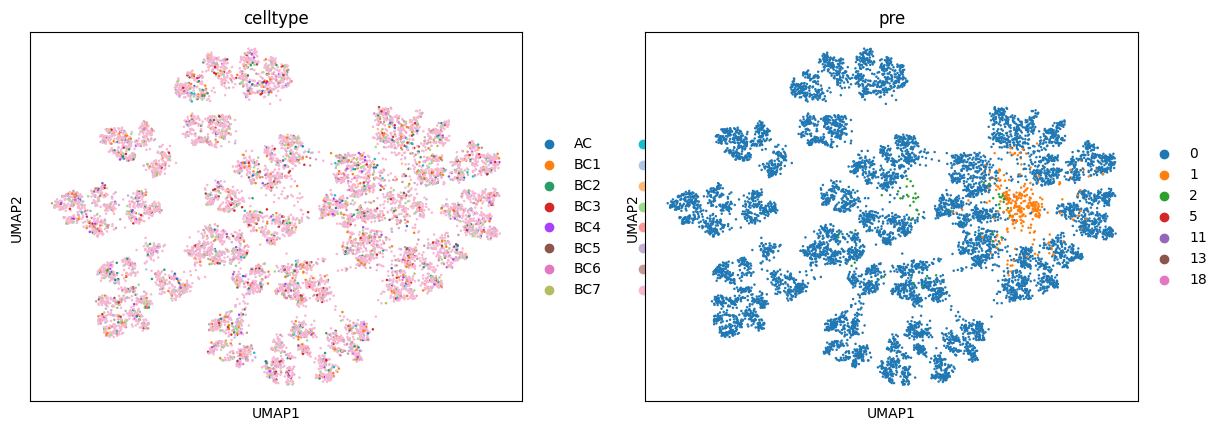

In [7]:
Node_Ids = np.load('data/mouse_retina_/output/Node_Ids.npy')
Node_Ids
cell_emb = np.load('data/mouse_retina_/output/cell_embedding.npy')
cell_emb_ = pd.DataFrame(cell_emb, index=Node_Ids)
cell_emb_sorted = cell_emb_.sort_index()
adata.obsm['cell_emb'] = cell_emb_sorted.values
pred = np.load('data/mouse_retina_/output/pred.npy')
pred_ = pd.DataFrame(pred, index=Node_Ids)
pred_sorted = pred_.sort_index()
adata.obs['pre'] = pred_sorted.values
adata.obs['pre'] = adata.obs['pre'].astype('category')
adata
adata.var_names_make_unique()
sc.pp.log1p(adata)
sc.pp.neighbors(adata, use_rep='cell_emb')
sc.tl.umap(adata)
sc.pl.umap(adata, color=['celltype', 'pre'], show=True)

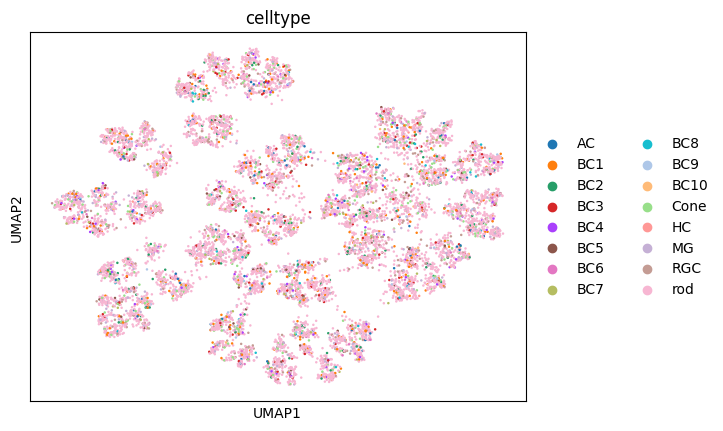

In [8]:
sc.pl.umap(adata, color='celltype', show=True)